## Problem 1 - Monte Carlo

In this problem, you will compare two Monte Carlo methods for estimating the probability that a standard normal distribution has a value greater than two (i.e., $P(Y > 2 | Y \sim N(0,1))$). For all parts of Problem 1, we will use $T=1000$.

### 1. (a) Naive Monte Carlo

The first method we will use is naive Monte Carlo. Monte Carlo estimates the expected value of a function of a random variable. The probability a random variable is greater than two can be written as an expectation of a function of a random variable --- it is the expected number of times that the random variable is greater than two if we drew a lot of samples from the distribution. So, $P(Y > 2) = E[I(Y>2)]$, where $I(\cdot)$ is an indicator function, which returns 1 when its argument is true and 0 otherwise.\footnote{In your favorite programming language, it is easy to calculate the probability that a standard normal distribution is greater than two --- e.g., simply run {\tt 1-normcdf(2,0,1) = 0.0228} in Matlab. However, I want you to implement these estimators to get a feel for how they behave.} 

Write code that samples $T$ standard normally distributed variables $x_{MC}^{(1)},\ldots, x_{MC}^{(T)} \sim N(0,1)$. Create a vector which cumulatively estimates the Monte Carlo estimate of the probability of seeing a value greater than two after observing each subsequent data point. 

In other words, create a vector ${\bf f}_{MC}$ such that the value of element $t$ in ${\bf f}_{MC}$ is the Markov Carlo estimate of the probability that a standard normal randomly generated value is greater than 2 from $t$ samples (the number of samples in $x_{MC}^{(1)},\ldots, x_{MC}^{(t)}$ that are greater than 2). 

Plot ${\bf f}_{MC}$ vector. Is there anything strange about it? (Does it look like the example we did in class of the Monte Carlo estimate of the average number of dots seen when you roll a die?) Write 1-2 sentences explaining why the plot of the updated Monte Carlo estimate looks the way it does. Also report the final estimate according to the Monte Carlo estimate ($f_{MC}(T)$).

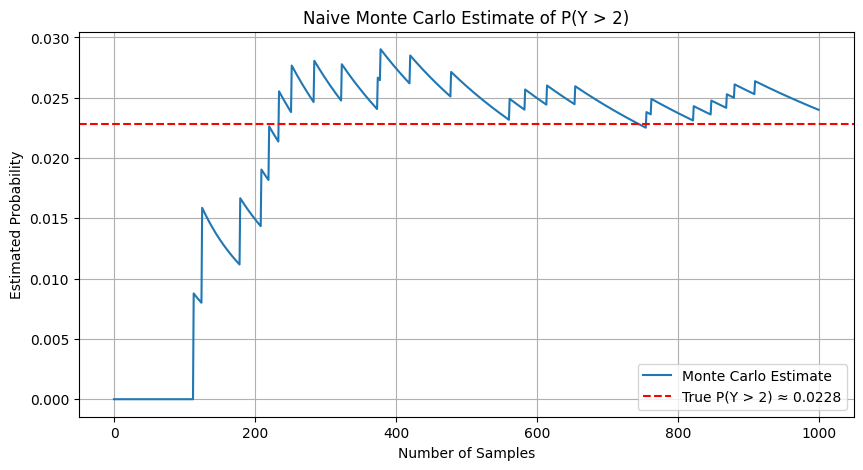

Final Monte Carlo estimate of P(Y > 2): 0.024


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# seed for reproducibility
np.random.seed(42)

# number of samples
T = 1000

# sampling from standard normal distribution
x_MC = np.random.normal(0, 1, T)

# applying indicator function
indicators = (x_MC > 2).astype(int)

# cumulative Monte Carlo estimate
fMC = np.cumsum(indicators) / np.arange(1, T + 1)

# plotting estimate
plt.figure(figsize=(10, 5))
plt.plot(fMC, label='Monte Carlo Estimate')
plt.axhline(y=1 - 0.9772, color='red', linestyle='--', label='True P(Y > 2) ≈ 0.0228')
plt.xlabel('Number of Samples')
plt.ylabel('Estimated Probability')
plt.title('Naive Monte Carlo Estimate of P(Y > 2)')
plt.legend()
plt.grid(True)
plt.show()

# final estimate
final_estimate = fMC[-1]
print(f"Final Monte Carlo estimate of P(Y > 2): {final_estimate}")

The plot fluctuates more at the beginning due to high variance from a small sample size, then gradually stabilizes around the true value (~0.0228) as more samples are included. This shows that as we average over more samples, the estimate becomes more accurate and less noisy.

### 1. (b) Importance Sampling
The second method we will use is called {\em importance sampling}. This is another method for estimating the expectation of a function of a random variable. Rather than using the distribution of the random variable itself to generate samples, it uses a different distribution ($q$ -- called the {\em proposal} distribution)\footnote{If you are curious why we use $q$ instead of $p$ for the probability under the proposal distribution, at least one reason is to remind us that $q$ is not the actual probability., Rather, it is a surrogate that we are using as part of our approximation method.} and then re-weights each sample by how probable they would have been under the true distribution. So, if $x_{IS}^{(1)},\dotsc,x_{IS}^{(T)}$ are my $T$ samples generated from distribution $q$ rather than $p$, my estimate would be
 
 \begin{equation*}
 \frac{1}{T}\sum_{t=1}^T{\frac{p\left(x_{IS}^{(t)} \right) }{q\left(x_{IS}^{(t)}\right) } I\left(x_{IS}^{(t)}>2 \right) }
 \end{equation*}
 
 Lets apply this to calculating the probability that $X > 2$ given $X \sim N(0,1)$. Because we are interested in the probability $X > 2$, lets use a distribution that is closer to 2:  $q=N(2,1)$.   So, samples from the proposal distribution come from $N(2,1)$ (a normal distribution with a mean of 2 and variance of 1). This can be drawn from a standard normal distribution (N(0,1)) from by adding two to a random variable generated from standard normal distribution.

One way to solve the problem then is to sample each data point from $q$ and then use a function that returns the probability density of some value under a Normal distribution with a specified mean and variance. Alternatively, you could divide $p$ by $q$ explicitly. The explicit solution is
 \begin{equation*}
 \frac{1}{T}\sum_{t=1}^T{ e^{-2 x_{IS}^{(t)} +2 } I (x_{IS}^{(t)} > 2)}
 \end{equation*}
 
 Now, make the same plot as in 1a, but now using the importance sampling estimate (i.e., plot a vector ${\bf f}^{IS}$ such that $f_t^{IS}$ is the importance sampling estimate of the probability that a standard normal randomly generated variable is greater than 2 using $q \sim N(2,1)$ after $t$ samples). Write 1-2 sentences explaining why the plot of the updated importance sampling estimate looks the way it does. Also, please report the importance sampling estimate given all of the samples.

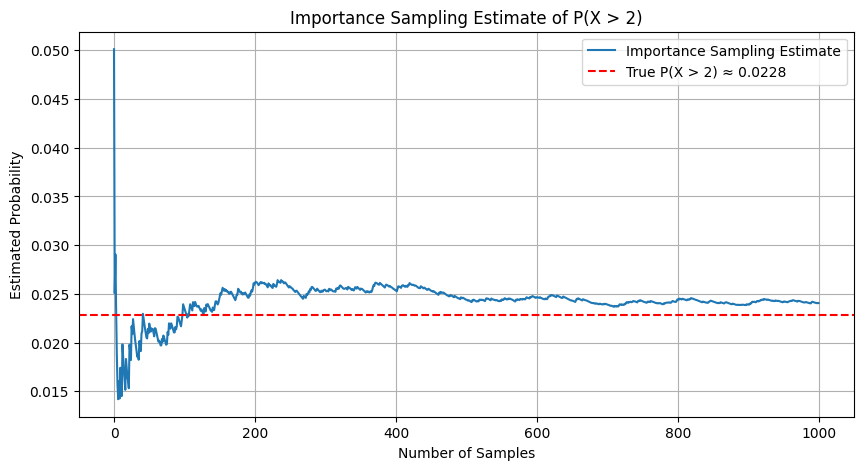

Final Importance Sampling estimate of P(X > 2): 0.024065948954931922


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# seed for reproducibility
np.random.seed(42)

# number of samples
T = 1000

# sampling from distribution q ~ N(2,1)
x_IS = np.random.normal(2, 1, T)

# indicator function for x > 2
indicators_IS = (x_IS > 2).astype(int)

# importance weights (based on the formula)
weights = np.exp(-2 * x_IS + 2)

# weighted indicator
weighted_indicators = weights * indicators_IS

# cumulative average (running estimate)
fIS = np.cumsum(weighted_indicators) / np.arange(1, T + 1)

# plot
plt.figure(figsize=(10, 5))
plt.plot(fIS, label='Importance Sampling Estimate')
plt.axhline(y=1 - 0.9772, color='red', linestyle='--', label='True P(X > 2) ≈ 0.0228')
plt.xlabel('Number of Samples')
plt.ylabel('Estimated Probability')
plt.title('Importance Sampling Estimate of P(X > 2)')
plt.legend()
plt.grid(True)
plt.show()

# final estimate
final_importance_estimate = fIS[-1]
print(f"Final Importance Sampling estimate of P(X > 2): {final_importance_estimate}")

The importance sampling plot stabilizes more quickly and with less variance than the naive Monte Carlo method. That’s because we’re sampling from a distribution (mean = 2) where values greater than 2 are much more common, so we get more effective samples in the region we care about. However, there’s still some noise due to the weight adjustments, especially early on.

### 1. (c) Compare and explain

Write a few sentences comparing Figures 1a and 1b: How and why do they differ? What is a broad lesson about Monte Carlo approximation that we can learn from this comparison?

In Figure 1a, the estimate fluctuates significantly, especially early on, because standard normal samples rarely exceed 2 - so most samples contribute 0 to the estimate. In contrast, Figure 1b shows a smoother, faster convergence. This is because importance sampling draws samples from a distribution centered near the threshold (i.e., N(2,1)), making samples that satisfy the condition x > 2 more frequent and informative.

The takeaway is that Monte Carlo approximation improves dramatically when the sampling distribution is aligned with the rare event or region of interest. Importance sampling is a powerful technique for variance reduction, especially when estimating probabilities of rare events.